### Intro:

This notebook analyzes changes in Land Surface Temperature (LST) over the past decade, with the goal of identifying regions that have experienced the most significant shifts. In the first section, we calculate the per-pixel temperature difference between the 2024 and 2014 LST layers. The second section generates a standard deviation layer based on this difference map to help identify anomalous changes.

To define outlier pixels, we apply a ±3 standard deviation threshold. This generous margin accounts for potential uncertainties introduced by satellite sensor limitations and post-processing procedures.

We mask out all pixels affected by cloud cover in either image and apply an additional 3-pixel buffer around these areas. This decision is informed by prior research, which indicates that satellite-derived LST values can be <a href="https://doi.org/10.1016/j.rse.2013.09.002">significantly underestimated</a> in the presence of cloud contamination.

Please note that this analysis is based on a limited dataset due to data availability constraints. As with any remote sensing product, results should be interpreted with consideration of inherent measurement uncertainties.

### Prep: Trim Layers to the area of interest, and align pixels for analysis

Note: The input bounding box should be of EPSG:4326

In [16]:
# Import packages
from osgeo import gdal, osr
from pyproj import Transformer
import numpy as np

In [17]:
def clipRasterToExtent(input_fn, output_fn, bounds_latlon, resample='near'):
    """
    Clips a raster to a bounding box specified in lat/lon (EPSG:4326).
    
    Parameters:
    - input_fn: str, input raster file path
    - output_fn: str, output raster file path
    - bounds_latlon: tuple of (minLon, minLat, maxLon, maxLat)
    - resample: str, resampling method: 'near', 'bilinear', etc.
    """
    # Open input raster and get its projection
    ds = gdal.Open(input_fn)
    proj_wkt = ds.GetProjection()
    srs = osr.SpatialReference()
    srs.ImportFromWkt(proj_wkt)
    target_epsg = srs.GetAttrValue("AUTHORITY", 1)
    if target_epsg is None:
        raise ValueError("Could not determine EPSG code of input raster")

    # Convert lat/lon bounds to raster CRS (typically UTM)
    transformer = Transformer.from_crs("EPSG:4326", f"EPSG:{target_epsg}", always_xy=True)
    min_lon, min_lat, max_lon, max_lat = bounds_latlon
    x_min, y_min = transformer.transform(min_lon, min_lat)
    x_max, y_max = transformer.transform(max_lon, max_lat)
    bounds_utm = (x_min, y_min, x_max, y_max)

    # Warp to clip raster
    gdal.Warp(
        output_fn,
        input_fn,
        outputBounds=bounds_utm,
        cropToCutline=False,
        dstNodata=np.nan,
        resampleAlg=resample
    )

### Step 1: Create difference in temperature layer and create mask for missing data.

In [18]:
# Import packages
from scipy.ndimage import binary_dilation

In [19]:
def openRaster(fn, access=0):
    ds = gdal.Open(fn, access)
    if ds is None:
        print("Error opening raster dataset")
    return ds

def getRasterBand(fn, band=1, access=0):
    ds = openRaster(fn, access)
    band_data = ds.GetRasterBand(band).ReadAsArray()
    return band_data

def createRasterFromCopy(fn, ds, data, driverFmt="GTiff"):
    driver = gdal.GetDriverByName(driverFmt)
    outds = driver.CreateCopy(fn, ds, strict=0)
    outband = outds.GetRasterBand(1)
    outband.WriteArray(data)
    if np.isnan(data).any():
        outband.SetNoDataValue(np.nan)
    outds = None

def subtractRasters(urlcurrentlayer, urlprevlayer, urlsubtractlayer):
    dataPrev = getRasterBand(urlprevlayer).astype(float)
    dataCurrent = getRasterBand(urlcurrentlayer).astype(float)

    # Initial NaN mask
    mask_nan = np.isnan(dataCurrent) | np.isnan(dataPrev)

    # Expand the NaN mask by 3 pixels in all directions
    buffer_mask = binary_dilation(mask_nan, iterations=3)

    # Subtract and apply expanded mask
    dataSubtract = dataCurrent - dataPrev
    dataSubtract[buffer_mask] = np.nan

    # Save result
    ds_ref = gdal.Open(urlprevlayer)
    createRasterFromCopy(urlsubtractlayer, ds_ref, dataSubtract)


### Step 2: Show distribution of the difference layer (Use this step as a verification for step 1)

In [20]:
# Import packages
import matplotlib.pyplot as plt

In [21]:
def showRasterDistributionWithOutliers(fn):
    data = getRasterBand(fn).astype(float).flatten()
    
    # Remove NaNs
    data_clean = data[~np.isnan(data)]
    
    # Basic statistics
    min_val = np.min(data_clean)
    max_val = np.max(data_clean)
    mean_val = np.mean(data_clean)
    std_val = np.std(data_clean)
    q1 = np.percentile(data_clean, 25)
    q3 = np.percentile(data_clean, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    print("Summary Statistics:")
    print(f"  Min: {min_val:.2f}")
    print(f"  Max: {max_val:.2f}")
    print(f"  Mean: {mean_val:.2f}")
    print(f"  Std Dev: {std_val:.2f}")
    print(f"  Q1: {q1:.2f}")
    print(f"  Q3: {q3:.2f}")
    print(f"  IQR: {iqr:.2f}")
    print(f"  Outlier Range: less than {lower_bound:.2f} or greater than {upper_bound:.2f}")

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(data_clean, bins=100, color='steelblue', edgecolor='black')
    plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Outlier Bound')
    plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Outlier Bound')
    plt.title("Distribution of Raster Difference Values")
    plt.xlabel("Difference Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Step 3: Create Standard Deviation layer

In [22]:
# Import packages
import os

In [24]:
def create_stddev_tiff(urlsubtractlayer, output_path):
    # Load dataset
    ds = gdal.Open(urlsubtractlayer)
    band = ds.GetRasterBand(1)
    array = band.ReadAsArray().astype(float)

    # Handle NoData
    nodata = band.GetNoDataValue()
    if nodata is not None:
        array[array == nodata] = np.nan

    # Compute global mean and std
    mean_val = np.nanmean(array)
    std_val = np.nanstd(array)

    # Compute per-pixel standardized score (z-score)
    std_array = (array - mean_val) / std_val

    # Write result to GeoTIFF
    driver = gdal.GetDriverByName("GTiff")
    rows, cols = std_array.shape
    out_ds = driver.Create(output_path, cols, rows, 1, gdal.GDT_Float32)
    out_ds.SetGeoTransform(ds.GetGeoTransform())
    out_ds.SetProjection(ds.GetProjection())

    out_band = out_ds.GetRasterBand(1)
    out_band.WriteArray(std_array)
    out_band.SetNoDataValue(-9999)
    out_band.FlushCache()

    # Clean up
    out_ds = None
    ds = None

    return output_path

### Run codes below for each city of interest

#### Charleston

In [ ]:
# Input the area of interest for each city
bounds = (-80.2701, 32.6628, -79.6523, 33.2467) 

# Input the downloaded LST tif
clipRasterToExtent("./Cleaned Layers/CHS_20140821_ST_Fahrenheit_cloudmasked.tif", "./Clipped Layers/CHS_20140821.tif", bounds)
clipRasterToExtent("./Cleaned Layers/CHS_20240715_ST_Fahrenheit_cloudmasked.tif", "./Clipped Layers/CHS_20240715.tif", bounds)

In [13]:
urlprevlayer = "./Clipped Layers/CHS_20140821.tif"
urlcurrentlayer = "./Clipped Layers/CHS_20240715.tif"
urlsubtractlayer = "./Difference/CHS_2014_2024_CHS.tif"

subtractRasters(urlcurrentlayer, urlprevlayer, urlsubtractlayer)

In [ ]:
output_path="./StandardDev/CHS_Standdev.tif"

create_stddev_tiff(urlsubtractlayer, output_path)

'./StandardDev/CHS_Standdev.tif'

Summary Statistics:
  Min: -281.60
  Max: 298.53
  Mean: 11.38
  Std Dev: 4.39
  Q1: 8.88
  Q3: 13.49
  IQR: 4.61
  Outlier Range: less than 1.96 or greater than 20.41


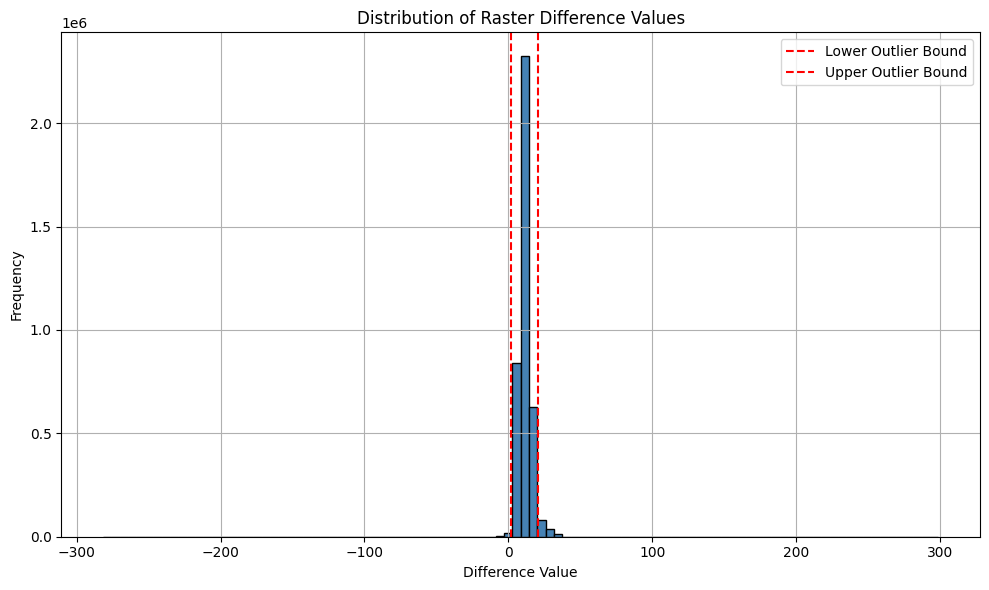

In [ ]:
showRasterDistributionWithOutliers(urlsubtractlayer)

#### Florence

In [26]:
# Input the area of interest for each city
bounds = (-79.95452, 34.10869, -79.61630, 34.32961) 

# Input the downloaded LST tif
clipRasterToExtent("./Cleaned Layers/FLO_20140821_ST_Fahrenheit_cloudmasked.tif", "./Clipped Layers/FLO_20140821.tif", bounds)
clipRasterToExtent("./Cleaned Layers/FLO_20240715_ST_Fahrenheit_cloudmasked.tif", "./Clipped Layers/FLO_20240715.tif", bounds)

In [27]:
urlprevlayer = "./Clipped Layers/FLO_20140821.tif"
urlcurrentlayer = "./Clipped Layers/FLO_20240715.tif"
urlsubtractlayer = "./Difference/FLO_2014_2024_CHS.tif"

subtractRasters(urlcurrentlayer, urlprevlayer, urlsubtractlayer)

In [28]:
output_path="./StandardDev/FLO_Standdev.tif"

create_stddev_tiff(urlsubtractlayer, output_path)

'./StandardDev/FLO_Standdev.tif'

Summary Statistics:
  Min: -17.74
  Max: 45.17
  Mean: 11.13
  Std Dev: 5.10
  Q1: 7.91
  Q3: 13.69
  IQR: 5.78
  Outlier Range: less than -0.77 or greater than 22.36


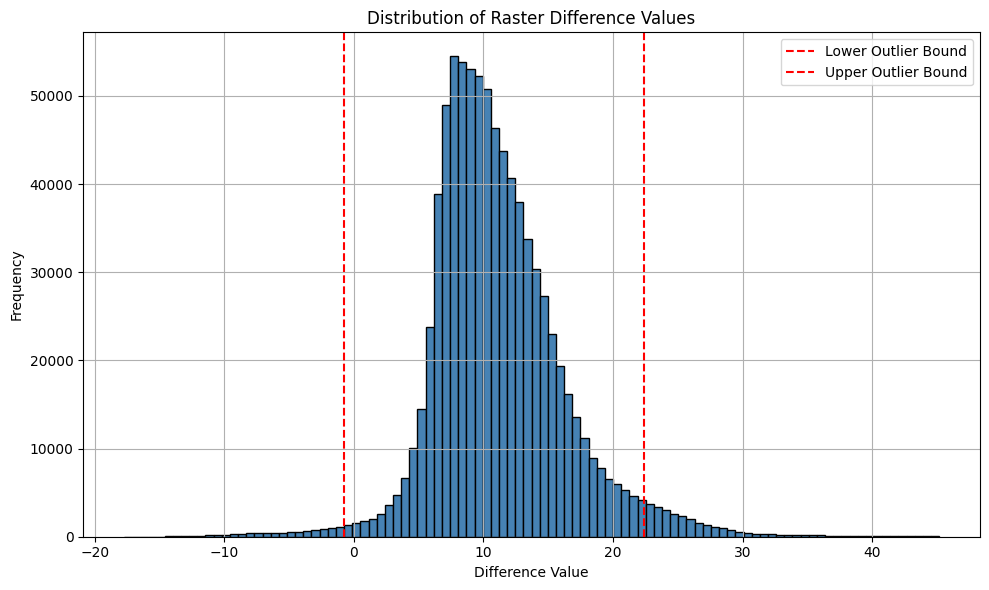

In [ ]:
showRasterDistributionWithOutliers(urlsubtractlayer)

#### Greenville/Spartanburg

In [30]:
# Input the area of interest for each city
bounds = (-82.5528, 35.0165, -81.7869, 34.7762) 

# Input the downloaded LST tif
clipRasterToExtent("./Cleaned Layers/GVL_20140702_ST_Fahrenheit_cloudmasked.tif", "./Clipped Layers/GVL_20140702.tif", bounds)
clipRasterToExtent("./Cleaned Layers/GVL_20240705_ST_Fahrenheit_cloudmasked.tif", "./Clipped Layers/GVL_20240705.tif", bounds)

In [31]:
urlprevlayer = "./Clipped Layers/GVL_20140702.tif"
urlcurrentlayer = "./Clipped Layers/GVL_20240705.tif"
urlsubtractlayer = "./Difference/GVL_2014_2024_CHS.tif"

subtractRasters(urlcurrentlayer, urlprevlayer, urlsubtractlayer)

In [32]:
output_path="./StandardDev/GVL_Standdev.tif"

create_stddev_tiff(urlsubtractlayer, output_path)

'./StandardDev/GVL_Standdev.tif'

Summary Statistics:
  Min: -34.48
  Max: 41.58
  Mean: 9.75
  Std Dev: 4.90
  Q1: 6.74
  Q3: 12.06
  IQR: 5.32
  Outlier Range: less than -1.23 or greater than 20.03


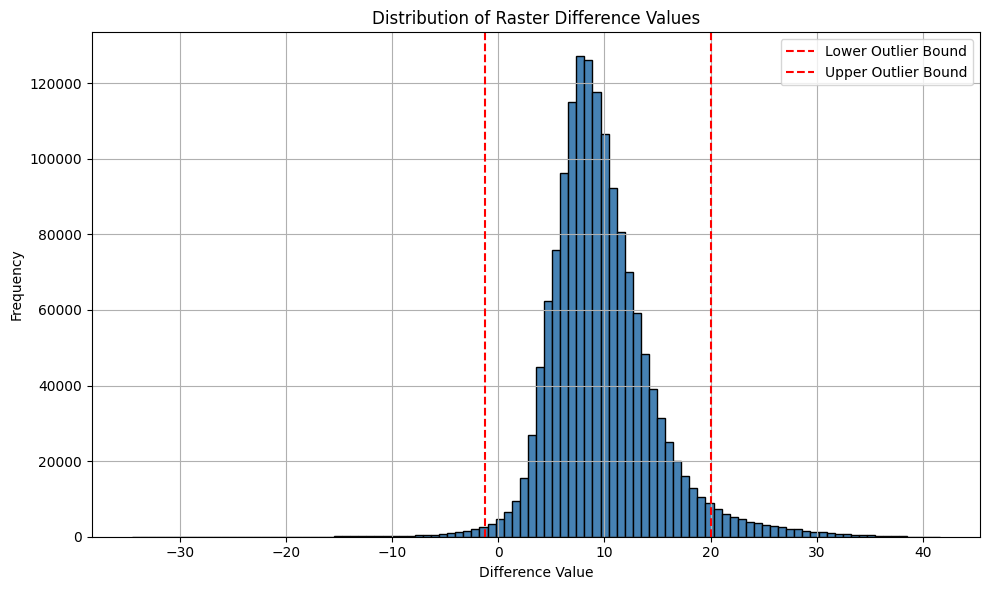

In [33]:
showRasterDistributionWithOutliers(urlsubtractlayer)

#### Columbia

In [34]:
# Input the area of interest for each city
bounds = (-81.3716, 34.2103, -80.7853, 33.8725) 

# Input the downloaded LST tif
clipRasterToExtent("./Cleaned Layers/CAE_20140828_ST_Fahrenheit_cloudmasked.tif", "./Clipped Layers/CAE_20140828.tif", bounds)
clipRasterToExtent("./Cleaned Layers/CAE_20240714_ST_Fahrenheit_cloudmasked.tif", "./Clipped Layers/CAE_20240714.tif", bounds)

In [35]:
urlprevlayer = "./Clipped Layers/CAE_20140828.tif"
urlcurrentlayer = "./Clipped Layers/CAE_20240714.tif"
urlsubtractlayer = "./Difference/CAE_2014_2024.tif"

subtractRasters(urlcurrentlayer, urlprevlayer, urlsubtractlayer)

In [36]:
output_path="./StandardDev/CAE_Standdev.tif"

create_stddev_tiff(urlsubtractlayer, output_path)

'./StandardDev/CAE_Standdev.tif'

Summary Statistics:
  Min: -56.58
  Max: 45.16
  Mean: 6.86
  Std Dev: 5.12
  Q1: 4.41
  Q3: 9.41
  IQR: 5.01
  Outlier Range: less than -3.11 or greater than 16.93


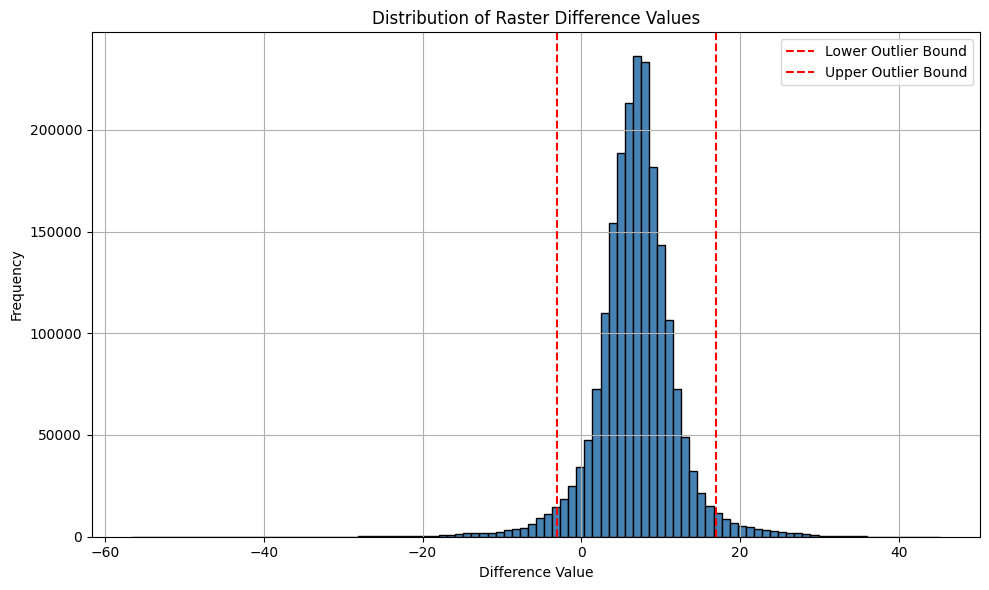

In [37]:
showRasterDistributionWithOutliers(urlsubtractlayer)